# Predicción temprana de riesgo de biomasa algal (HABs) a 0–7 días
### Notebook reproducible — sistema causal sin fuga

Este notebook reemplaza los notebooks antiguos (que tenían **fuga de datos**: AUC≈1.0 falso por
target derivado de las mismas bandas + validación con *shuffle*). Aquí el problema es **pronóstico
causal** X(≤t₀) → clorofila-a(t₀+h), con validación temporal honesta.

> El sistema es una **herramienta de alerta temprana** de condiciones de riesgo (biomasa /
> clorofila-a elevada), **no** un detector certero de toxicidad: la confirmación de nocividad
> requiere verificación de campo (cianobacterias, toxinas).

## 0. Configuración e imports

In [1]:
import os, sys, json, subprocess, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
from train import FEATURES, SPECTRAL, AUTOREG, ERA5, NUTRIENTS, WATERQUAL, PAIRS, _model
print("Horizontes:", [h for h in C.HORIZONS if h != 0], "| grupos:", C.GROUPS)

Horizontes: [1, 3, 5, 7] | grupos: ('freshwater', 'marine')


## 1. Pares causales (predictor en t₀ → target en t₀+h)
Cada fila empareja el **estado espectral Sentinel-2 en t₀** (+ clorofila reciente, ERA5, in-situ)
con la **clorofila-a satelital en t₀+h** (VIIRS/OLCI, sensor independiente → rompe la circularidad).
El target en t₀+h **nunca** es predictor.

In [2]:
df = pd.read_csv(PAIRS, parse_dates=["fecha_t0", "fecha_target"])
print(f"Pares: {len(df)} | cuerpos: {sorted(df.water_body.unique())}")
display(df.groupby(["group","water_body"]).size().rename("pares").to_frame())
# causalidad: para h>0 el target es estrictamente futuro
viol = df[(df.horizon>0) & (df.fecha_target<=df.fecha_t0)]
print(f"Pares con fuga temporal (target<=t0, h>0): {len(viol)}  -> 0 = sin fuga")

Pares: 4371 | cuerpos: ['cajon', 'fonseca', 'okeechobee', 'tampa_bay', 'yojoa']


pares
group      water_body       
freshwater cajon         315
           okeechobee   1726
           yojoa         395
marine     fonseca      1033
           tampa_bay     902

Pares con fuga temporal (target<=t0, h>0): 0  -> 0 = sin fuga


## 2. Test de integridad (sin fuga / causal / consistente)
Se ejecuta el script `check_integrity.py` que afirma 11 condiciones de honestidad.

In [3]:
r = subprocess.run([sys.executable, "check_integrity.py"], capture_output=True, text=True)
print(r.stdout[-1200:])

CHECK DE INTEGRIDAD DEL PIPELINE (sin fuga / causal / consistente)
[OK]   Ninguna feature contaminada/prohibida en FEATURES
[OK]   NDVI NO es predictor (solo QA)
[OK]   Backbone autorregresivo (log_chl_t0) presente
[OK]   Sin fuga temporal: target h>0 estrictamente futuro
[OK]   gap_real dentro de HORIZON_TOLERANCE
[OK]   Todas las FEATURES presentes en los pares
[OK]   El target no aparece como feature
[OK]   Sin pares duplicados exactos
[OK]   thr_body presente y > 0
[OK]   Modelos: features validas + intervalos (CQR) guardados
[OK]   Features de los modelos sin columnas de target
11/11 OK



## 3. Familias de features (todas causales, ≤ t₀)
- **AUTOREG**: trayectoria reciente de clorofila (backbone).
- **SPECTRAL**: bandas/índices Sentinel-2 (NDCI, CI_red, FAI, turbidez).
- **ERA5**: meteorología (temp, radiación, precipitación, viento).
- **INSITU**: fósforo + calidad de agua (contexto de medio/largo plazo).

In [4]:
for name, fam in [("AUTOREG",AUTOREG),("SPECTRAL",SPECTRAL),("ERA5",ERA5),
                  ("INSITU",NUTRIENTS+WATERQUAL)]:
    print(f"{name:9s}: {fam}")

AUTOREG  : ['log_chl_t0', 'chl_lag3', 'chl_lag7', 'chl_roll7', 'chl_trend7']
SPECTRAL : ['B2', 'B3', 'B4', 'B5', 'B8', 'NDCI', 'CI_red', 'FAI', 'turbidity']
ERA5     : ['temp_air_2m', 'solar_radiation', 'precipitation', 'wind_speed_10m', 'surface_pressure', 'temp_air_2m_roll7', 'solar_radiation_roll7', 'precipitation_roll7', 'wind_speed_10m_roll7']
INSITU   : ['tp_context', 'water_temp', 'do_mgl', 'ph', 'turbidity_insitu', 'spec_cond', 'secchi', 'ammonia']


## 4. Validación anidada — TEST FINAL INTACTO
Se reserva el último ~25% del tiempo como test nunca tocado; la selección de features se hace
solo en DEV. Es el **número defendible**. `*` = IC95% bootstrap excluye 0 (skill significativo).

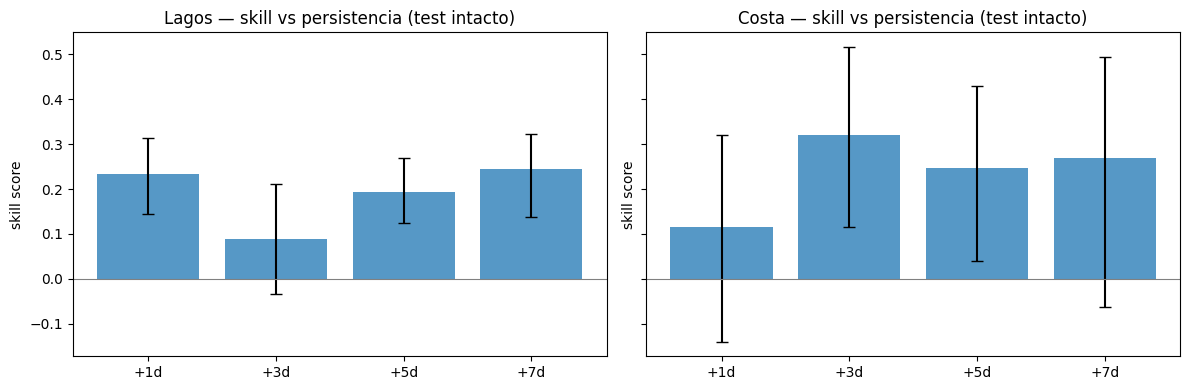

,freshwater,marine
+1d,+0.23,+0.11
+3d,+0.09,+0.32
+5d,+0.19,+0.25
+7d,+0.24,+0.27


In [5]:
rep = json.load(open(os.path.join(C.DIR_REPORTS,"nested_metrics.json")))
fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True)
for ax,(grp,nm) in zip(axes, [("freshwater","Lagos"),("marine","Costa")]):
    hs=[1,3,5,7]; med=[rep[grp][str(h)]["skill_nested"][0] for h in hs]
    lo=[rep[grp][str(h)]["skill_nested"][1] for h in hs]; hi=[rep[grp][str(h)]["skill_nested"][2] for h in hs]
    err=[[m-l for m,l in zip(med,lo)],[h2-m for m,h2 in zip(med,hi)]]
    ax.bar([f"+{h}d" for h in hs], med, color="#2c7fb8", alpha=.8)
    ax.errorbar([f"+{h}d" for h in hs], med, yerr=err, fmt="none", ecolor="k", capsize=4)
    ax.axhline(0, color="grey", lw=.8); ax.set_title(f"{nm} — skill vs persistencia (test intacto)")
    ax.set_ylabel("skill score")
plt.tight_layout(); plt.show()
pd.DataFrame({grp:{f"+{h}d": f"{rep[grp][str(h)]['skill_nested'][0]:+.2f}" for h in [1,3,5,7]}
             for grp in ["freshwater","marine"]})

## 5. Intervalos de incertidumbre (regresión cuantil conformalizada, CQR)
Cada pronóstico de intensidad lleva una banda **P10–P90**. Validada en el test intacto:
cobertura empírica cercana a **0.80** = intervalos calibrados (no sobreconfiados).

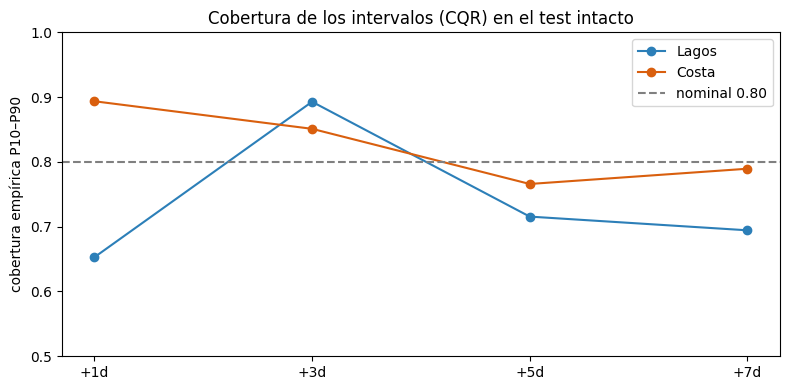

In [6]:
iv = json.load(open(os.path.join(C.DIR_REPORTS,"interval_metrics.json")))
fig, ax = plt.subplots(figsize=(8,4))
for grp,nm,c in [("freshwater","Lagos","#2c7fb8"),("marine","Costa","#d95f0e")]:
    hs=[1,3,5,7]; cov=[iv[grp][str(h)]["cobertura_cqr"][0] for h in hs]
    ax.plot([f"+{h}d" for h in hs], cov, "o-", color=c, label=nm)
ax.axhline(0.80, ls="--", color="grey", label="nominal 0.80")
ax.set_ylim(0.5,1.0); ax.set_ylabel("cobertura empírica P10–P90"); ax.legend()
ax.set_title("Cobertura de los intervalos (CQR) en el test intacto"); plt.tight_layout(); plt.show()

## 6. Sensibilidad ERA5 (reanálisis vs pronóstico)
Ablación (aporte real de ERA5) y estrés de ruido. Aporte pequeño + curva plana ⇒ se puede operar con ERA5 de pronóstico sin perder skill.

In [7]:
er = json.load(open(os.path.join(C.DIR_REPORTS,"era5_sensitivity.json")))
rows=[]
for grp in ["freshwater","marine"]:
    for h in [1,3,5,7]:
        nd=er[grp][str(h)]
        rows.append({"grupo":grp,"h":f"+{h}d","skill_con_ERA5":round(nd["skill_con_era5"][0],3),
                     "aporte_ERA5":round(nd["aporte_era5"],3),
                     "skill_ruido_100%":round(nd["ruido_curva"]["1.0"][0],3)})
pd.DataFrame(rows)

,grupo,h,skill_con_ERA5,aporte_ERA5,skill_ruido_100%
0,freshwater,+1d,0.170,-0.007,0.168
1,freshwater,+3d,0.158,0.043,0.110
2,freshwater,+5d,0.116,-0.021,0.079
3,freshwater,+7d,0.219,0.016,0.215
4,marine,+1d,-0.014,-0.040,0.002
5,marine,+3d,0.134,-0.001,0.124
6,marine,+5d,0.116,0.023,0.098
7,marine,+7d,0.172,0.015,0.173


## 7. Predicción desplegable (ejemplo)
`predict.py` produce, para un cuerpo y fecha, la clorofila-a esperada por horizonte + **banda de
incertidumbre** + probabilidad de **riesgo** calibrada (sí/no).

In [8]:
r = subprocess.run([sys.executable, "predict.py", "okeechobee"], capture_output=True, text=True)
print(r.stdout)


=== OKEECHOBEE (freshwater) | t0=2026-05-09 | chl-a actual=4.0 ug/L | biomasa alta (chl-a)>=42.8 ug/L | dispara si prob>=0.06 ===
  horizonte  chl-a_pred(ug/L)    banda P10-P90  prob_riesgo   RIESGO
  +1d                   20.4         3.5-54.0         0.16       SI
  +3d                   12.0         6.6-35.5         0.05       no
  +5d                   16.9         4.0-28.3         0.16       SI
  +7d                    8.4         1.8-31.9         0.05       no
  Nota: RIESGO = biomasa algal elevada (clorofila-a anomala), NO confirma toxicidad; requiere verificacion de campo.
  Banda P10-P90 = intervalo de incertidumbre calibrado (CQR, cobertura ~80%).



## 8. Demostración en vivo: el modelo supera a la persistencia
Entrenamiento rápido (un cuerpo, walk-forward temporal) para ilustrar que el pronóstico tiene
skill real frente al baseline de persistencia (proyectar el último valor conocido).

In [9]:
from sklearn.metrics import mean_squared_error
feats = [f for f in FEATURES if f in df.columns]
d = df[(df.water_body=="okeechobee") & (df.horizon==5)].sort_values("fecha_t0")
cut = d.fecha_t0.quantile(0.75)
tr, te = d[d.fecha_t0<=cut], d[d.fecha_t0>cut]
m = _model().fit(tr[feats], tr.log_chl_target)
rmse_model = np.sqrt(mean_squared_error(te.log_chl_target, m.predict(te[feats])))
rmse_persist = np.sqrt(mean_squared_error(te.log_chl_target, te.log_chl_t0))
print(f"Okeechobee +5d | RMSE(log) modelo={rmse_model:.3f}  persistencia={rmse_persist:.3f}")
print(f"Skill = {1 - rmse_model/rmse_persist:+.2f}  (>0 => mejor que persistencia)")

Okeechobee +5d | RMSE(log) modelo=1.157  persistencia=1.290
Skill = +0.10  (>0 => mejor que persistencia)


## Reproducir todo
```bash
pip install -r ../requirements.txt
python run_pipeline.py        # build_scene_state -> ... -> build_final_report
python check_integrity.py     # 11/11 OK
```
Los datos pesados (rasters Sentinel-2, ERA5) se descargan con `fetch_*` / `ingest_*`
(ver `run_pipeline.py`). **Conclusión:** pronóstico causal 0–7 d con skill significativo en lagos,
alerta en costa, intervalos calibrados y herramienta de riesgo (no de confirmación de nocividad).